# **Naira to Dollar Exchange Rate Forecast**

This notebook presents a data-driven approach to forecasting the Nigeria–US forex rate using historical time series data. The workflow combines exploratory data analysis (EDA), feature engineering, and machine learning / deep learning models to uncover trends, seasonality, and volatility patterns inherent in the exchange rate movements.

Specifically, the notebook will:

 - Model the exchange rate – using multiple forecasting approaches including:

 - Classical statistical models (ARIMA, SARIMA, VAR)

 - Machine learning models (Random Forest, XGBoost)

 - Deep learning models (LSTM, GRU, or Transformer-based architectures)

 - Evaluate and compare model performance using metrics such as RMSE, MAE, and MAPE.

 - Select the best-performing model for robust short-term and long-term forecasting.

By the end of this notebook, we aim to build a forecasting pipeline capable of producing accurate, explainable, and adaptive predictions of the NGN/USD exchange rate

In [19]:
# import required pacakges
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import statsmodels.api as sm
from sklearn.metrics import r2_score
from tqdm.auto import tqdm
import warnings
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [20]:
warnings.filterwarnings("ignore")
random.seed(12345)

In [21]:
# load features
df_feat = pd.read_csv('../../data/03_features/ngn_us_exchange_rates_features.csv')

# Display the feature engineered data
df_feat.head()

,Date,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
0,1997-04-11,84.66,-0.29,0.00,0.00,-0.040,0.000,0.08,1.24,-0.22,...,-3.685185,-inf,-0.879167,-1.973154,-6.800000,-0.768000,-1.58,4,11,1997
1,1997-05-02,85.05,0.25,0.00,0.00,0.108,0.560,0.00,0.06,0.30,...,-1.862069,-0.722222,2.125000,-7.250000,inf,-1.297619,inf,5,2,1997
2,1997-05-09,84.48,-0.32,0.25,0.00,0.000,0.900,0.00,0.00,0.08,...,-inf,-3.962963,-6.333333,-inf,0.454545,-1.780488,-1.80,5,9,1997
3,1997-05-16,84.48,0.02,-0.32,0.25,0.000,0.108,-0.04,0.00,0.06,...,inf,inf,inf,-1.909091,-0.600000,-0.900000,-0.96,5,16,1997
4,1997-05-23,84.96,0.41,0.02,-0.32,-0.290,0.000,0.56,0.00,0.00,...,0.640000,inf,inf,-2.863636,-1.745455,inf,inf,5,23,1997


In [22]:
# Convert transaction_time column to date format
df_feat["Date"] = pd.to_datetime(df_feat["Date"], errors="coerce")
df_feat.set_index("Date", inplace=True)

In [23]:
# Replace infinities with NaN, inspect and clean
df_feat.replace([np.inf, -np.inf], 0, inplace=True)

In [24]:
# Train-test split (time split)
test_size = int(len(df_feat)*0.012)
train = df_feat.iloc[:-test_size].copy()
test = df_feat.iloc[-test_size:].copy()

print("Train range:", train.index.min().date(), "to", train.index.max().date())
print("Test range:", test.index.min().date(), "to", test.index.max().date())

Train range: 1997-04-11 to 2025-07-18
Test range: 2025-07-25 to 2025-10-17


In [25]:
# Fit SARIMAX model 
mod = SARIMAX(
    endog=train['Rate'],
    exog=train.drop("Rate", axis=1),
    order=(2,1,2),
    seasonal_order=(2,1,1,52),
)

In [26]:
# Test the model and plot results
res = mod.fit(disp=False)
fcst = res.forecast(steps=len(test), exog = test.drop("Rate", axis=1))

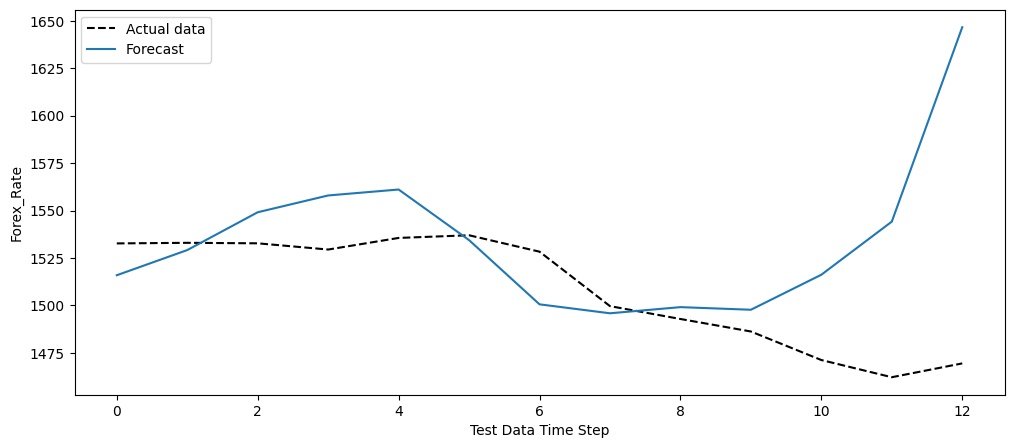

In [ ]:
plt.figure(figsize=(12,5))
sarimax_mape = np.mean(np.abs(fcst - test["Rate"])/np.abs(test["Rate"])) * 100
plt.plot(list(test["Rate"]), color="black", linestyle="--")
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Forex_Rate')
plt.xlabel('Test Data Time Step')
plt.text(0, min(fcst), f"SARIMAX MAPE: {sarimax_mape:.2f}%", fontsize=12, color="black")
plt.show()